In [3]:
# ============================================================
# STEP 1 — PREPROCESSING ENVIRONMENT SETUP
# ============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms

print("Preprocessing environment ready")
print("Python executable:", os.sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Preprocessing environment ready
Python executable: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


In [3]:
# ============================================================
# STEP 2 — DATASET PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "GroceryStoreDataset-master"
    / "dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

CLASSES_CSV = DATASET_ROOT / "classes.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)

print("\nChecking dataset paths...")

for name, path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Classes CSV": CLASSES_CSV,
}.items():
    print(f"{'OK' if path.exists() else 'MISSING':8} {name}: {path}")

Project root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
Dataset root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking dataset paths...
OK       Train: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train
OK       Validation: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val
OK       Test: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test
OK       Classes CSV: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv


#Load the class metadata

In [4]:
# ============================================================
# STEP 3 — LOAD CLASS METADATA
# ============================================================

classes_df = pd.read_csv(CLASSES_CSV)

print("Classes CSV loaded successfully")
print("Shape:", classes_df.shape)

print("\nColumns:")
print(classes_df.columns.tolist())

print("\nFirst 10 classes:")
display(
    classes_df[
        [
            "Class Name (str)",
            "Class ID (int)",
            "Coarse Class Name (str)",
            "Coarse Class ID (int)"
        ]
    ].head(10)
)

# Basic validation
assert classes_df["Class ID (int)"].nunique() == 81
assert classes_df["Class ID (int)"].min() == 0
assert classes_df["Class ID (int)"].max() == 80

print("\nFine-grained classes:", classes_df["Class ID (int)"].nunique())
print(
    "Coarse-grained categories:",
    classes_df["Coarse Class ID (int)"].nunique()
)
print("Class metadata validation: PASSED")

Classes CSV loaded successfully
Shape: (81, 6)

Columns:
['Class Name (str)', 'Class ID (int)', 'Coarse Class Name (str)', 'Coarse Class ID (int)', 'Iconic Image Path (str)', 'Product Description Path (str)']

First 10 classes:


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int)
0,Golden-Delicious,0,Apple,0
1,Granny-Smith,1,Apple,0
2,Pink-Lady,2,Apple,0
3,Red-Delicious,3,Apple,0
4,Royal-Gala,4,Apple,0
5,Avocado,5,Avocado,1
6,Banana,6,Banana,2
7,Kiwi,7,Kiwi,3
8,Lemon,8,Lemon,4
9,Lime,9,Lime,5



Fine-grained classes: 81
Coarse-grained categories: 43
Class metadata validation: PASSED


#Load train, validation, and test labels

In [5]:
# ============================================================
# STEP 4 — LOAD DATASET LABEL FILES
# ============================================================

LABEL_COLUMNS = [
    "image_path",
    "fine_class_id",
    "coarse_class_id"
]

train_df = pd.read_csv(
    DATASET_ROOT / "train.txt",
    header=None,
    names=LABEL_COLUMNS
)

val_df = pd.read_csv(
    DATASET_ROOT / "val.txt",
    header=None,
    names=LABEL_COLUMNS
)

test_df = pd.read_csv(
    DATASET_ROOT / "test.txt",
    header=None,
    names=LABEL_COLUMNS
)

print("Dataset label files loaded successfully\n")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

print("\nTotal images:",
      len(train_df) + len(val_df) + len(test_df))

print("\nTrain sample:")
display(train_df.head())

print("\nValidation sample:")
display(val_df.head())

print("\nTest sample:")
display(test_df.head())

Dataset label files loaded successfully

Train      : (2640, 3)
Validation : (296, 3)
Test       : (2485, 3)

Total images: 5421

Train sample:


,image_path,fine_class_id,coarse_class_id
0,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
1,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
2,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
3,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
4,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0



Validation sample:


,image_path,fine_class_id,coarse_class_id
0,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
1,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
2,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
3,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
4,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0



Test sample:


,image_path,fine_class_id,coarse_class_id
0,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
1,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
2,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
3,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
4,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0


Verify label consistency

In [6]:
# ============================================================
# STEP 5 — LABEL CONSISTENCY VALIDATION
# ============================================================

print("=" * 70)
print("LABEL CONSISTENCY VALIDATION")
print("=" * 70)

# Create fine → coarse mapping from classes.csv
fine_to_coarse = dict(
    zip(
        classes_df["Class ID (int)"],
        classes_df["Coarse Class ID (int)"]
    )
)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    
    # Check fine-class IDs
    invalid_fine = ~df["fine_class_id"].isin(
        classes_df["Class ID (int)"]
    )
    
    # Check coarse-class IDs
    invalid_coarse = ~df["coarse_class_id"].isin(
        classes_df["Coarse Class ID (int)"]
    )
    
    # Check fine → coarse relationship
    mapping_errors = df.apply(
        lambda row: fine_to_coarse.get(row["fine_class_id"])
        != row["coarse_class_id"],
        axis=1
    )
    
    print(f"\n{split_name}")
    print("-" * 70)
    print("Invalid fine-class IDs   :", invalid_fine.sum())
    print("Invalid coarse-class IDs :", invalid_coarse.sum())
    print("Fine → coarse errors     :", mapping_errors.sum())

print("\n" + "=" * 70)
print("LABEL VALIDATION COMPLETED")
print("=" * 70)

LABEL CONSISTENCY VALIDATION

Train
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Validation
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Test
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

LABEL VALIDATION COMPLETED


Inspect actual training images


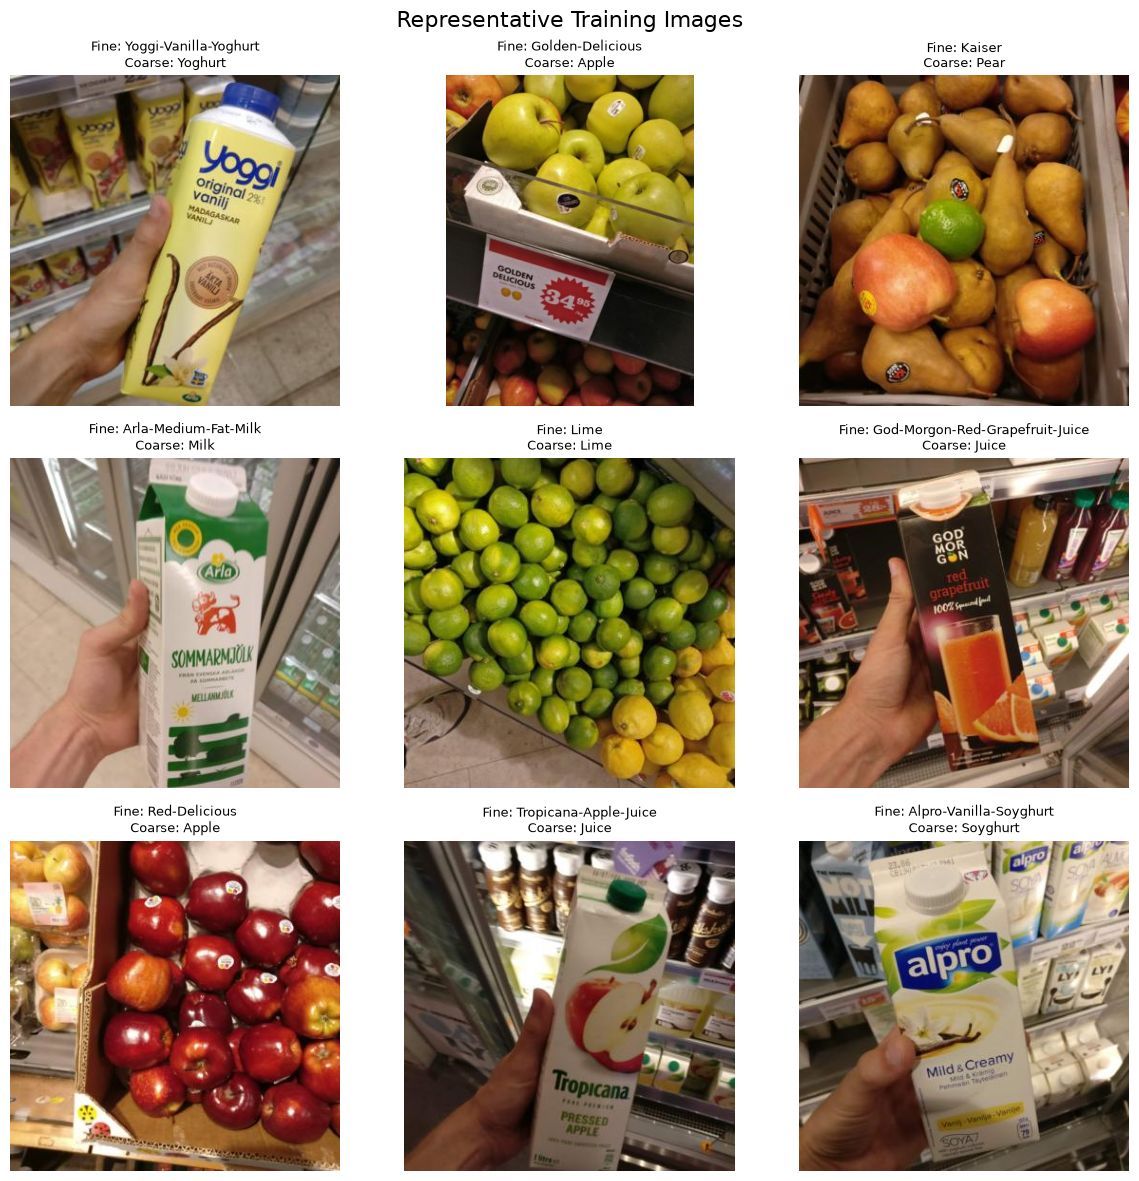

In [8]:
# ============================================================
# STEP 6 — VISUAL INSPECTION OF TRAINING IMAGES
# ============================================================

# Select 9 representative training samples
sample_df = train_df.sample(
    n=9,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    # image_path already contains "train/..."
    image_path = DATASET_ROOT / row["image_path"]

    image = Image.open(image_path).convert("RGB")

    fine_id = int(row["fine_class_id"])
    coarse_id = int(row["coarse_class_id"])

    fine_name = classes_df.loc[
        classes_df["Class ID (int)"] == fine_id,
        "Class Name (str)"
    ].iloc[0]

    coarse_name = classes_df.loc[
        classes_df["Coarse Class ID (int)"] == coarse_id,
        "Coarse Class Name (str)"
    ].iloc[0]

    ax.imshow(image)
    ax.set_title(
        f"Fine: {fine_name}\nCoarse: {coarse_name}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle(
    "Representative Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()